In [1]:
# import statements
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
# this cell will take a minute to run depending on your internet connection
X, y = fetch_openml('mnist_784', version=1, return_X_y=True) # getting data from online
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (70000, 784) y shape: (70000,)


In [3]:
# this cell processes some of the data

# if this returns an error of the form "KeyError: 0", then try running the following first:
X = X.values # this converts X from a pandas dataframe to a numpy array

digits = {j:[] for j in range(10)}
for j in range(len(y)): # takes data assigns it into a dictionary
    digits[int(y[j])].append(X[j].reshape(28,28))
digits = {j:np.stack(digits[j]) for j in range(10)} # stack everything to be one numpy array
for j in range(10):
    print('Shape of data with label', j, ':', digits[j].shape )

Shape of data with label 0 : (6903, 28, 28)
Shape of data with label 1 : (7877, 28, 28)
Shape of data with label 2 : (6990, 28, 28)
Shape of data with label 3 : (7141, 28, 28)
Shape of data with label 4 : (6824, 28, 28)
Shape of data with label 5 : (6313, 28, 28)
Shape of data with label 6 : (6876, 28, 28)
Shape of data with label 7 : (7293, 28, 28)
Shape of data with label 8 : (6825, 28, 28)
Shape of data with label 9 : (6958, 28, 28)


In [4]:
# this cell would stack 100 examples from each class together
# this cell also ensures that each pixel is a flot between 0 and 1 instead of an int between 0 and 255
data = []
for i in range(10):
    flattened_images = digits[i][:100].reshape(100,-1)
    data.append(flattened_images)
    
data = np.vstack(data)
data = data.astype('float32') / 255.0

In [10]:
# label data
X49 = np.vstack([digits[4][:500], digits[9][:500]])
y49 = np.hstack([-np.ones(500, dtype=np.int8), np.ones(500, dtype=np.int8)])

X49 = X49.reshape(1000, 784).astype("float") / 255.0

rng = np.random.default_rng(0)
perm = rng.permutation(len(y49))
X49, y49 = X49[perm], y49[perm]

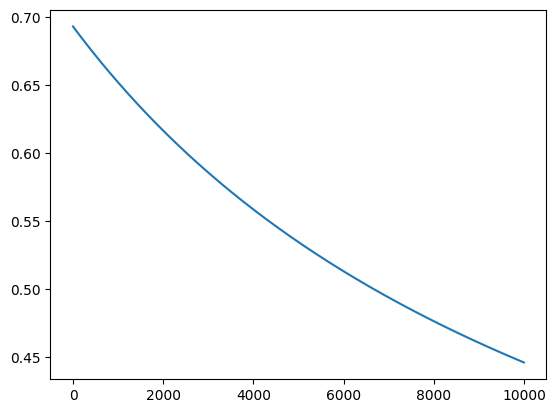

In [7]:
# Run Gradient Descent
X = X49
y = y49.astype(np.float32)
n, d = X.shape

mu = 1e-4
T  = 10000
w  = np.zeros(d)

def logistic_loss(w):
    z = y * (X @ w)
    return np.mean(np.log1p(np.exp(-z)))

def logistic_grad(w):
    z = y * (X @ w)
    s = 1.0 / (1.0 + np.exp(z))
    return -(X.T @ (y * s)) / n

vals = []
for t in range(T):
    vals.append(logistic_loss(w))
    w -= mu * logistic_grad(w)

plt.plot(vals)
plt.show()

In [11]:
# Train and Test Error
X_test = np.vstack([digits[4][500:1000], digits[9][500:1000]])
y_test = np.hstack([-np.ones(500), np.ones(500)])
X_test = X_test.reshape(1000, 784).astype('float') / 255.0

y_pred_tr = np.sign(X @ w)
y_pred_te = np.sign(X_test @ w)

train_error = np.mean(y_pred_tr != y)
test_error  = np.mean(y_pred_te != y_test)

print(train_error)
print(test_error)

0.081
0.103


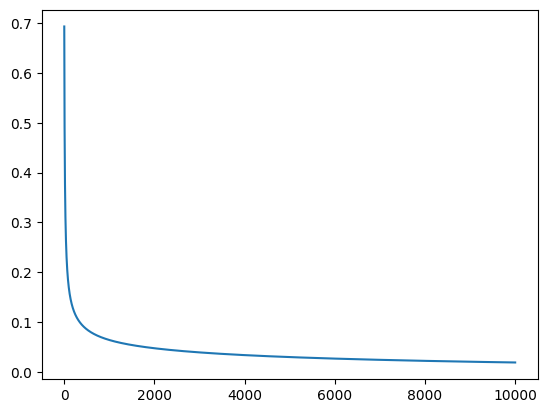

In [13]:
mu0   = 1e-1
gamma = 0.5
beta  = 0.8
T     = 10000

w = np.zeros(d)
vals = []

for t in range(T):
    F_w = logistic_loss(w)
    vals.append(F_w)

    g = logistic_grad(w)
    mu = mu0

    while True:
        w_new = w - mu * g
        F_new = logistic_loss(w_new)
        if F_new <= F_w - gamma * mu * np.linalg.norm(g)**2:
            break
        mu *= beta
    w = w_new

plt.plot(vals)
plt.show()